# Imputation of Categorical column

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('E:/Dataset/advance-house-price-pred.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [10]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [18]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

## Column which have less no of NaN value

Text(0, 0.5, 'No. of houses')

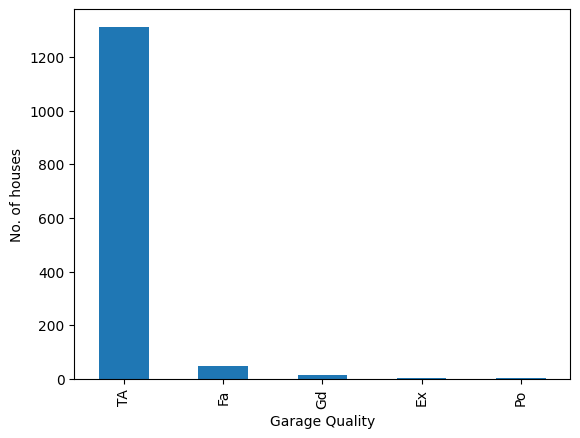

In [27]:
df['GarageQual'].value_counts().plot(kind='bar')
plt.xlabel('Garage Quality')
plt.ylabel('No. of houses')

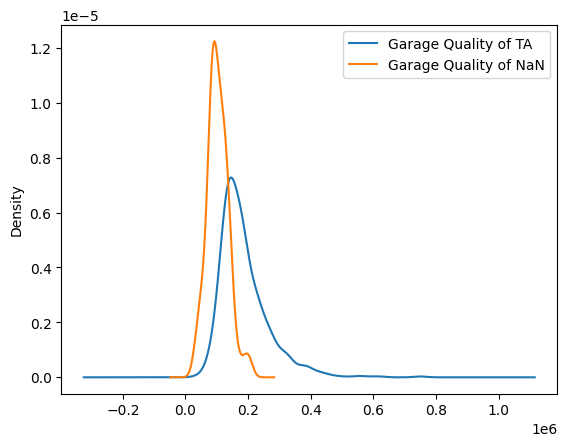

In [43]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde')
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde')

lines, labels = ax.get_legend_handles_labels()
labels = ['Garage Quality of TA', 'Garage Quality of NaN']
plt.legend(lines, labels)

### Imputing mode value

In [54]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

In [44]:
temp = df[df['GarageQual']=='TA']['SalePrice']

In [47]:
df['GarageQual'].fillna('TA', inplace=True)

<Axes: xlabel='GarageQual'>

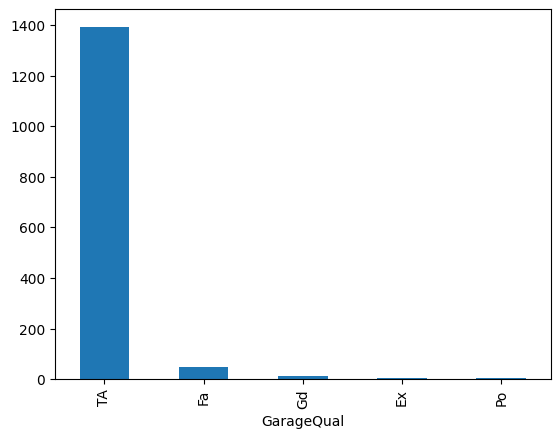

In [49]:
df['GarageQual'].value_counts().plot(kind='bar')

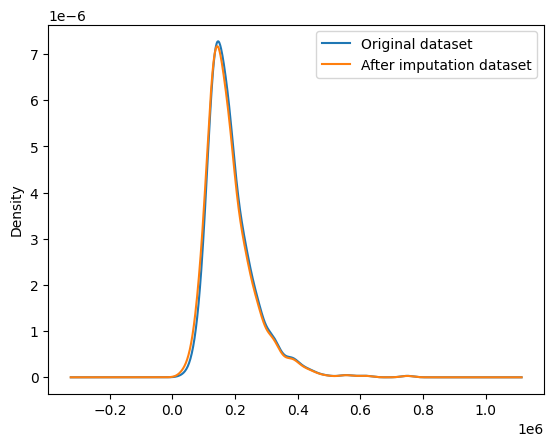

In [59]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde')
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original dataset', 'After imputation dataset']
plt.legend(lines, labels)

## Column which have high no of NaN value

<Axes: xlabel='FireplaceQu'>

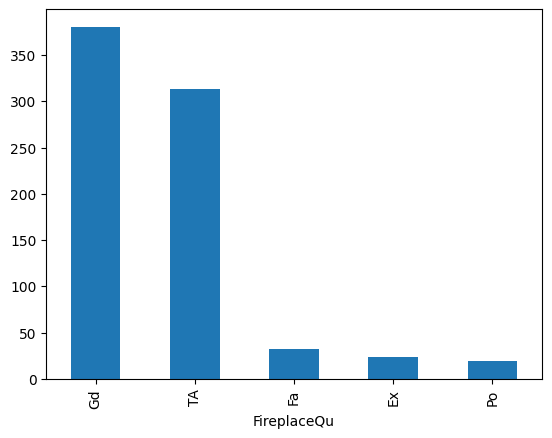

In [56]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [57]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

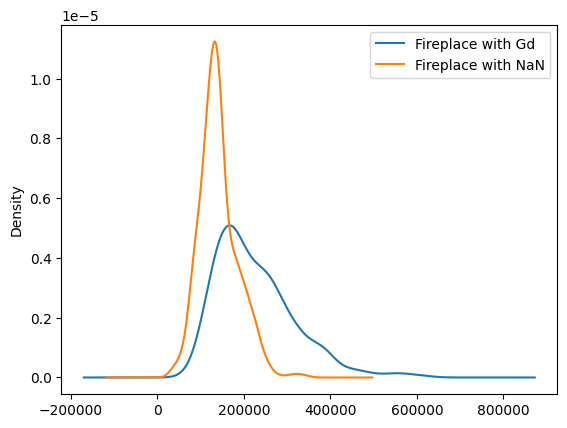

In [62]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu']=='Gd'].plot(kind='kde', ax=ax)
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax)

lines, labels = ax.get_legend_handles_labels()
labels = ['Fireplace with Gd', 'Fireplace with NaN']
plt.legend(lines, labels)

In [64]:
temp1 = df[df['FireplaceQu']=='Gd']['SalePrice']

In [66]:
df['FireplaceQu'].fillna('Gd', inplace=True)

<Axes: xlabel='FireplaceQu'>

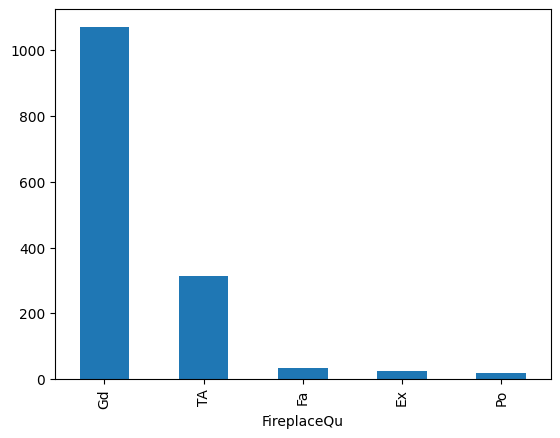

In [70]:
df['FireplaceQu'].value_counts().plot(kind='bar')

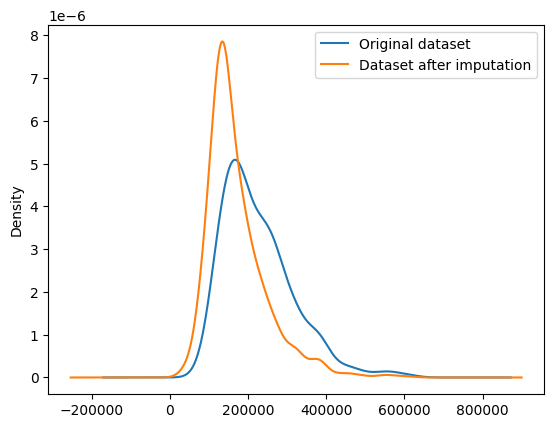

In [71]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp1.plot(kind='kde', ax=ax)
df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', ax=ax)

lines, labels = ax.get_legend_handles_labels()
labels = ['Original dataset', 'Dataset after imputation']
plt.legend(lines, labels)

## Using sklearn

In [72]:
from sklearn.model_selection import train_test_split

In [73]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns=['SalePrice']), df['SalePrice'], test_size=0.2, random_state=3)

In [75]:
from sklearn.impute import SimpleImputer

In [76]:
imputer = SimpleImputer(strategy='most_frequent')

In [77]:
imputer.fit(x_train)

,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [79]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)

In [80]:
x_train_trf = imputer.transform(x_train)

In [81]:
x_train_trf

array([['Gd', 'TA'],
       ['Gd', 'TA'],
       ['Gd', 'TA'],
       ...,
       ['Gd', 'TA'],
       ['Gd', 'TA'],
       ['Gd', 'TA']], shape=(1168, 2), dtype=object)